# 블로그 raw 데이터 품질 분석
- 데이터: `data/raw/블로그_전체상품_통합(분석식품대상).csv` (포스트 단위, 23,016행)
- 목적: 포스트별 품질 피처를 계산하여 필터링 기준 수립

**분석 순서**
1. 기본 현황 파악
2. 포스트별 품질 피처 계산
3. 피처별 분포 및 이상치 탐색
4. 이상치 샘플 육안 확인
5. 필터링 기준 결정

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RAW_CSV = os.path.join(PROJECT_ROOT, 'data', 'raw', '블로그_전체상품_통합(분석식품대상).csv')

df = pd.read_csv(RAW_CSV, encoding='utf-8-sig')
df['본문내용'] = df['본문내용'].fillna('')

print(f'전체 포스트: {len(df):,}행')
print(f'고유 검색어: {df["검색어"].nunique():,}개')
print(f'컬럼: {df.columns.tolist()}')
print()
posts_per_query = df.groupby('검색어').size()
print('검색어당 포스트 수 분포:')
print(posts_per_query.value_counts().sort_index())

전체 포스트: 23,016행
고유 검색어: 8,120개
컬럼: ['중분류명', '검색어', '블로그제목', '블로그링크', '본문내용']

검색어당 포스트 수 분포:
1     580
2     199
3    7336
6       5
Name: count, dtype: int64


## Step 1-b. 수집 실패 데이터 식별
- 본문 내용 중 '크롤링 오류', '본문 추출 실패' 등 수집 과정에서의 에러 메시지가 포함된 경우를 식별함
- 이들은 품질 분석 대상이 아닌 '수집 실패' 데이터로 우선 분류함

In [2]:
error_patterns = ['크롤링 오류', '본문 추출 실패', '추출 실패']
df['is_collected'] = ~df['본문내용'].str.contains('|'.join(error_patterns), na=False)
df.loc[df['본문내용'].str.strip() == '', 'is_collected'] = False

collect_summary = df['is_collected'].value_counts().to_frame(name='count')
collect_summary['ratio(%)'] = (collect_summary['count'] / len(df) * 100).round(2)

print('=== 수집 성공 여부 요약 ===')
print(collect_summary)

if not df['is_collected'].all():
    print(f'\n=== 수집 실패 샘플 ===')
    display(df[~df['is_collected']][['검색어', '본문내용']].head(5))

=== 수집 성공 여부 요약 ===
              count  ratio(%)
is_collected                 
True          22423     97.42
False           593      2.58

=== 수집 실패 샘플 ===


,검색어,본문내용
16,세븐일레븐 롯데)자일리톨F24g,
24,세븐일레븐 코카)몬스터(파이프라인펀치)355,크롤링 오류
92,세븐일레븐 그린)NEW참치김치볶음밥삼각,크롤링 오류
95,세븐일레븐 그린)스팸김치볶음밥삼각,크롤링 오류
104,세븐일레븐 동서)스타벅스오리지날,본문 추출 실패


## Step 2. 포스트별 품질 피처 계산

| 피처 | 설명 | 불량 신호 |
|------|------|-----------|
| `body_len` | 본문 길이 (자) | 너무 짧거나 너무 김 |
| `num_lines` | 줄 수 | — |
| `mean_line_len` | 평균 줄 길이 | 매우 짧으면 목록형 |
| `line_len_std` | 줄 길이 표준편차 | 낮으면 반복 목록 |
| `ttr` | 고유 단어 / 전체 단어 (Type-Token Ratio) | 낮으면 반복 패턴 |
| `num_ratio` | 숫자 문자 비율 | 높으면 가격/주소 목록 |
| `korean_ratio` | 한글 문자 비율 | 낮으면 비한국어 잡문 |

In [3]:
def compute_features(body: str) -> dict:
    if not body.strip():
        return dict(body_len=0, num_lines=0, mean_line_len=0,
                    line_len_std=0, ttr=0, num_ratio=0, korean_ratio=0)

    lines = [l for l in body.split('\n') if l.strip()]
    line_lens = [len(l) for l in lines]

    tokens = re.findall(r'[가-힣a-zA-Z0-9]+', body)
    ttr = len(set(tokens)) / len(tokens) if tokens else 0

    total_chars = len(body)
    num_ratio  = len(re.findall(r'[0-9]', body)) / total_chars
    kor_ratio  = len(re.findall(r'[가-힣]', body)) / total_chars

    return dict(
        body_len      = total_chars,
        num_lines     = len(lines),
        mean_line_len = np.mean(line_lens) if line_lens else 0,
        line_len_std  = np.std(line_lens)  if line_lens else 0,
        ttr           = round(ttr, 4),
        num_ratio     = round(num_ratio, 4),
        korean_ratio  = round(kor_ratio, 4),
    )

feats = df['본문내용'].apply(compute_features).apply(pd.Series)
df = pd.concat([df, feats], axis=1)

print('=== 피처 기술통계 ===')
print(df[feats.columns].describe(percentiles=[.25,.5,.75,.9,.95,.99]).round(3))

=== 피처 기술통계 ===
         body_len  num_lines  mean_line_len  line_len_std        ttr  \
count   23016.000  23016.000      23016.000     23016.000  23016.000   
mean     2805.039    102.728         32.167        27.386      0.757   
std     12799.459    331.151         90.092       167.120      0.156   
min         0.000      0.000          0.000         0.000      0.000   
25%       808.000     29.000         16.425         6.530      0.703   
50%      1335.500     52.000         21.282        11.700      0.785   
75%      2112.250     90.000         32.835        23.693      0.851   
90%      3475.000    154.000         51.836        46.644      0.904   
95%      5585.000    259.250         71.149        63.459      0.933   
99%     34173.300   1324.850        119.280       103.000      1.000   
max    868584.000  24947.000       5422.714      6011.288      1.000   

       num_ratio  korean_ratio  
count  23016.000     23016.000  
mean       0.044         0.635  
std        0.054    

In [11]:
df[df['body_len'] == max(df['body_len'])]

,중분류명,검색어,블로그제목,블로그링크,본문내용,is_collected,body_len,num_lines,mean_line_len,line_len_std,ttr,num_ratio,korean_ratio,quality_tag
6113,캔디류,세븐일레븐 그레)비달페인터캔디(봉지),pc서버 ㄷㅏΑ운 다운로드⌒ю,https://blog.naver.com/ytzobee/30126717788,pc서버 ㄷㅏΑ운 다운로드T\n?그것을 알기에 그의 동료들은 아운을 방해하지 않고 ...,True,868584.0,24947.0,33.817172,10.910876,0.2948,0.1171,0.3332,low_ttr


## Step 3. 피처별 분포 시각화

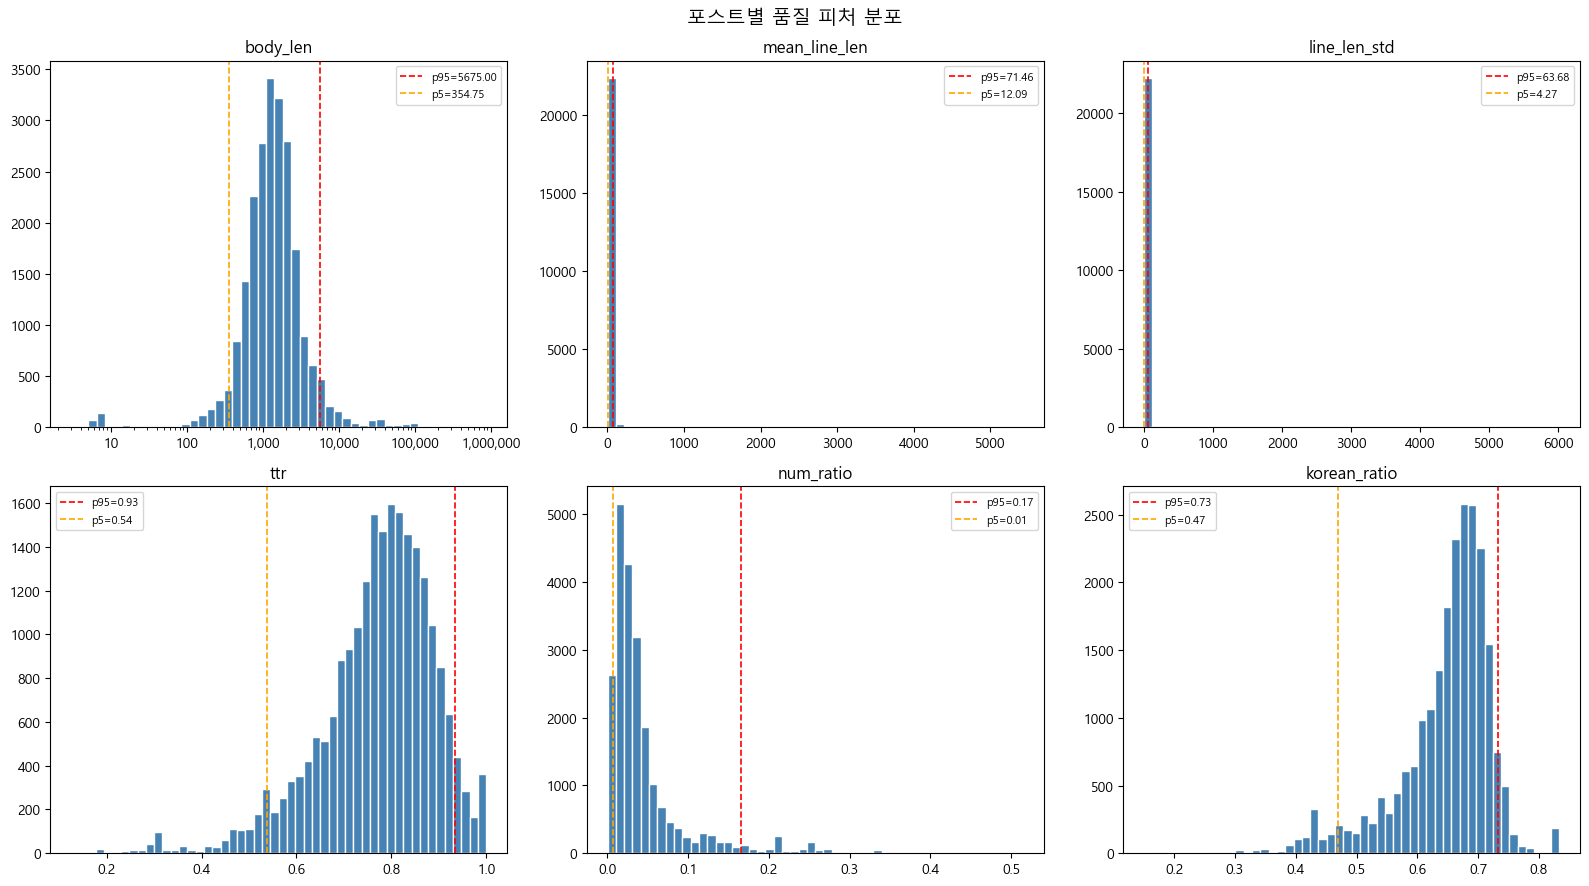

In [4]:
feat_cols = ['body_len', 'mean_line_len', 'line_len_std', 'ttr', 'num_ratio', 'korean_ratio']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, feat_cols):
    vals = df[col][df[col] > 0]
    if col == 'body_len':
        log_bins = np.logspace(np.log10(vals.clip(lower=1).min()), np.log10(vals.max()), 50)
        ax.hist(vals, bins=log_bins, color='steelblue', edgecolor='white')
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    else:
        ax.hist(vals, bins=50, color='steelblue', edgecolor='white')
    p95 = vals.quantile(0.95)
    p5  = vals.quantile(0.05)
    ax.axvline(p95, color='red',    linestyle='--', linewidth=1.2, label=f'p95={p95:.2f}')
    ax.axvline(p5,  color='orange', linestyle='--', linewidth=1.2, label=f'p5={p5:.2f}')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('포스트별 품질 피처 분포', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4. 이상치 샘플 육안 확인
각 피처의 극단값(상위/하위 5%) 포스트 본문을 직접 확인

In [5]:
PREVIEW_LEN = 300  # 본문 미리보기 길이
N_SAMPLE    = 8    # 구간당 샘플 수

def show_samples(label, mask, n=N_SAMPLE):
    sub = df[mask].sample(min(n, mask.sum()), random_state=42)
    print(f'\n{"="*70}')
    print(f'[{label}]  {mask.sum()}건')
    print('='*70)
    for _, row in sub.iterrows():
        preview = row['본문내용'][:PREVIEW_LEN].replace('\n', ' / ')
        print(f'  검색어: {row["검색어"]}')
        print(f'  body_len={row["body_len"]:,}  mean_line={row["mean_line_len"]:.1f}  '
              f'std={row["line_len_std"]:.1f}  ttr={row["ttr"]:.3f}  '
              f'num%={row["num_ratio"]*100:.1f}  kor%={row["korean_ratio"]*100:.1f}')
        print(f'  {preview}')
        print()

# 각 피처 이상치 구간
show_samples('body_len 상위 5% (너무 긴 포스트)',  df['body_len'] >= df['body_len'].quantile(0.95))
show_samples('body_len 하위 5% (너무 짧은 포스트)', (df['body_len'] > 0) & (df['body_len'] <= df['body_len'].quantile(0.05)))
show_samples('mean_line_len 하위 5% (줄이 짧음 → 목록형)', (df['mean_line_len'] > 0) & (df['mean_line_len'] <= df['mean_line_len'].quantile(0.05)))
show_samples('ttr 하위 5% (반복 패턴)',  (df['ttr'] > 0) & (df['ttr'] <= df['ttr'].quantile(0.05)))
show_samples('num_ratio 상위 5% (숫자 많음 → 가격/주소 목록)', df['num_ratio'] >= df['num_ratio'].quantile(0.95))
show_samples('korean_ratio 하위 5% (한글 적음)', (df['korean_ratio'] > 0) & (df['korean_ratio'] <= df['korean_ratio'].quantile(0.05)))


[body_len 상위 5% (너무 긴 포스트)]  1151건
  검색어: 세븐일레븐 에이플)몰랑이피규어캔디10g
  body_len=37,093.0  mean_line=23.5  std=3.0  ttr=0.299  num%=25.2  kor%=42.7
  ★1+1★ / 농심)데이플러스콜라겐500ML - 2,200원 / 농심)데이플러스프로틴500ML - 2,200원 / 덴마크)테이크얼라이브제로톡400 - 2,500원 / 덴마크)프룻믹스제로500ML - 2,500원 / 크리스탈라이트)레몬아이스드10T - 7,700원 / 크리스탈라이트)체리석류10T - 7,700원 / 크리스탈라이트)피치망고10T - 7,700원 / 크리스탈라이트)핑크레몬10T - 7,700원 / 안동간고등어100G(순살/냉동) - 5,000원 / 노가리먹태1입 - 6,900원 / 녹차녹차돌자반55G - 3,300원 / 파래파래돌자반55G - 3,300원 / 광동)헛

  검색어: 세븐일레븐 PB)오가다레몬꿀물280ml(8입 판매용) 
  body_len=23,703.0  mean_line=74.5  std=46.5  ttr=0.556  num%=1.2  kor%=61.7
  안녕하세요, 낭만적인 여행의 조각들을 모으는 수집가 '아리에티'입니다.🌿 / 다들 하얀 눈밭의 삿포로를 떠올리시만, 사실 삿포로의 초록빛 계절도 정말 매력있다는 거 아시나요? / 지난 8월, 예랑이와 떠난 "삿포로 가야하는 곳, 먹어야하는 음식 다 즐기자!"는 목표로 꽉 채워 다녀온 4박 5일 삿포로 여행기를 꺼내봅니다. 꽃내음 가득한 비에이 후라노 투어부터 입에서 살살 녹는 가성비 징기스칸까지! / 실패 없는 커플 여행 코스, 지금부터 제 수집품들을 펼쳐볼게요. 📷 / ✈️ 아리에티's 삿포로 4박 5일 일정표 / 1일차 (스스키노): 신치토세 공

  검색어: 세븐일레븐 동그린)빙꽃바사과80ml
  body_len=9,281.0  mean_line=1851.4  std=3616.9  ttr=0.582  num%=14.8

### Step 4-b. 품질 지표(Num/Kor/TTR) 기반 이상치 판별 로직
- 단순 하위/상위 5%가 아닌, 분석에 실제 악영향을 주는 임계값을 적용하여 이상치를 판별함
- **숫자 비중 25% 초과**, **한글 비중 30% 미만**, **TTR 0.3 미만**을 기준으로 '품질 태그'를 부여하여 이상치 유형 분석

In [6]:
def identify_outliers(row):
    reasons = []
    if row['num_ratio'] > 0.25: reasons.append('high_num_ratio')
    if row['korean_ratio'] < 0.3: reasons.append('low_korean_ratio')
    if row['ttr'] < 0.3: reasons.append('low_ttr')
    return ', '.join(reasons) if reasons else 'normal'

df['quality_tag'] = df.apply(identify_outliers, axis=1)
quality_summary = df['quality_tag'].value_counts().to_frame(name='count')
quality_summary['ratio(%)'] = (quality_summary['count'] / len(df) * 100).round(2)

print('=== 품질 지표별 이상치 현황 (중복 포함) ===')
print(quality_summary)
print(f'\n이상치 전체 비율: {(df["quality_tag"] != "normal").mean()*100:.1f}%')

# 복합 이상치(이유가 2개 이상) 샘플 확인
multi_outliers = df[df['quality_tag'].str.contains(',')]
if not multi_outliers.empty:
    print(f'\n=== 복합 이상치 샘플 ({len(multi_outliers)}건) ===')
    display(multi_outliers[['검색어', 'num_ratio', 'korean_ratio', 'ttr', 'quality_tag']].head(5))

=== 품질 지표별 이상치 현황 (중복 포함) ===
                                           count  ratio(%)
quality_tag                                               
normal                                     22164     96.30
low_korean_ratio, low_ttr                    384      1.67
high_num_ratio                               321      1.39
low_ttr                                       55      0.24
high_num_ratio, low_ttr                       54      0.23
low_korean_ratio                              27      0.12
high_num_ratio, low_korean_ratio               8      0.03
high_num_ratio, low_korean_ratio, low_ttr      3      0.01

이상치 전체 비율: 3.7%

=== 복합 이상치 샘플 (449건) ===


,검색어,num_ratio,korean_ratio,ttr,quality_tag
16,세븐일레븐 롯데)자일리톨F24g,0.0000,0.0000,0.0,"low_korean_ratio, low_ttr"
143,세븐일레븐 동아)박카스F120ml,0.0000,0.0000,0.0,"low_korean_ratio, low_ttr"
147,세븐일레븐 훼밀리)복숭아무케루푸루푸루구미40g,0.0000,0.0000,0.0,"low_korean_ratio, low_ttr"
209,세븐일레븐 코카)토레타제로500ml,0.2833,0.1667,1.0,"high_num_ratio, low_korean_ratio"
251,세븐일레븐 현대)미에로화이바350ml,0.0000,0.0000,0.0,"low_korean_ratio, low_ttr"


### Step 4-c. 핵심 3대 지표(Body/Num/Kor) 이상치 교집합 분석
- p5, p95를 벗어나는 '극단값' 데이터 중, `body_len`, `num_ratio`, `korean_ratio` 세 지표 모두에서 이상치인 데이터 탐색
- 이들은 모든 품질 기준에서 동시에 벗어난 '초고위험군' 스팸/노이즈 후보임

In [7]:
def get_outlier_mask(col):
    p05 = df[col].quantile(0.05)
    p95 = df[col].quantile(0.95)
    return (df[col] < p05) | (df[col] > p95)

mask_body = get_outlier_mask('body_len')
mask_num  = get_outlier_mask('num_ratio')
mask_kor  = get_outlier_mask('korean_ratio')

# 3개 지표 모두 이상치인 교집합
mask_intersect = mask_body & mask_num & mask_kor

print(f'=== 핵심 3대 지표 이상치 교집합 분석 ===')
print(f'1. body_len 이상치: {mask_body.sum():,}건')
print(f'2. num_ratio 이상치: {mask_num.sum():,}건')
print(f'3. korean_ratio 이상치: {mask_kor.sum():,}건')
print(f'\n>>> 세 지표 모두 이상치인 교집합 건수: {mask_intersect.sum():,}건')

if mask_intersect.any():
    print(f'\n=== 교집합 데이터 샘플 (상위 10건) ===')
    cols_to_show = ['검색어', 'body_len', 'num_ratio', 'korean_ratio', '본문내용']
    sample_df = df[mask_intersect][cols_to_show].head(100)
    # 본문내용은 100자만 미리보기
    sample_df['본문내용'] = sample_df['본문내용'].str[:500].str.replace('\n', ' ')
    display(sample_df)

=== 핵심 3대 지표 이상치 교집합 분석 ===
1. body_len 이상치: 2,302건
2. num_ratio 이상치: 2,296건
3. korean_ratio 이상치: 2,262건

>>> 세 지표 모두 이상치인 교집합 건수: 962건

=== 교집합 데이터 샘플 (상위 10건) ===


,검색어,body_len,num_ratio,korean_ratio,본문내용
16,세븐일레븐 롯데)자일리톨F24g,0.0,0.0000,0.0000,
24,세븐일레븐 코카)몬스터(파이프라인펀치)355,6.0,0.0000,0.8333,크롤링 오류
51,세븐일레븐 롯데)L와인샤도네이750ml,5675.0,0.2155,0.4275,#세븐일레븐 #이달의와인 #와인트렌드 #4월의와인 #711 #이벤트 #와인 #편의점...
92,세븐일레븐 그린)NEW참치김치볶음밥삼각,6.0,0.0000,0.8333,크롤링 오류
95,세븐일레븐 그린)스팸김치볶음밥삼각,6.0,0.0000,0.8333,크롤링 오류
...,...,...,...,...,...
2154,세븐일레븐 엠탑)까먹는복숭아젤리60g,8.0,0.0000,0.7500,본문 추출 실패
2156,세븐일레븐 포러스)연태고량주250ml,8.0,0.0000,0.7500,본문 추출 실패
2176,세븐일레븐 삼경)필러즈미스터리큐브46g,0.0,0.0000,0.0000,
2190,세븐일레븐 롯데)유기야채농장190ml,8.0,0.0000,0.7500,본문 추출 실패


## Step 5. 피처 간 상관 및 필터링 기준 결정
- 각 피처의 이상치 기준값을 직접 설정하고 필터 적용 결과 확인

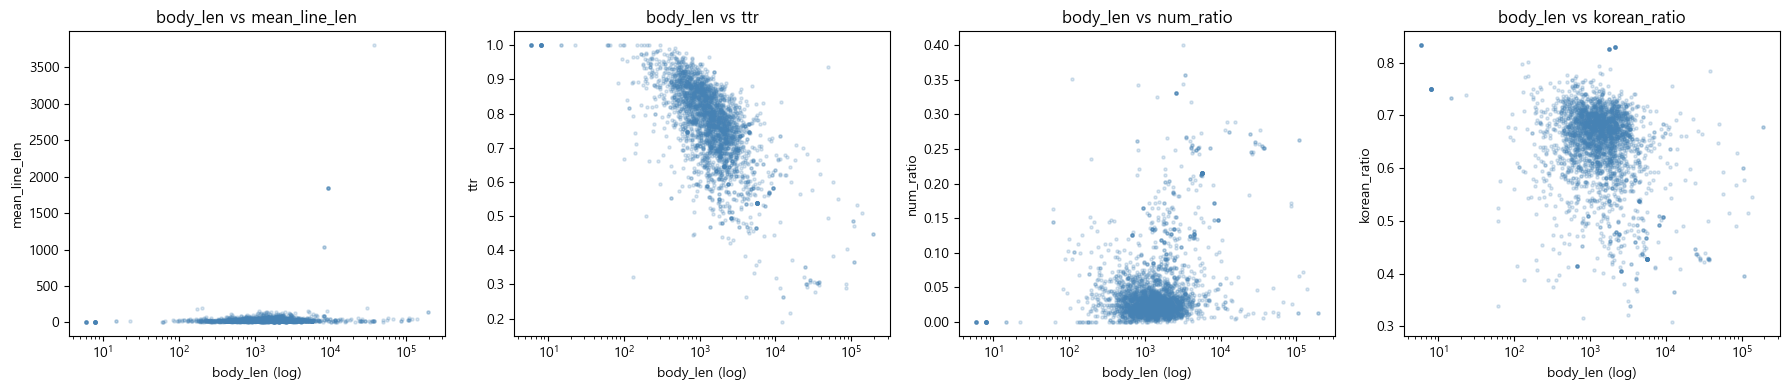

In [8]:
# 피처 간 산점도 (body_len vs 나머지)
compare_cols = ['mean_line_len', 'ttr', 'num_ratio', 'korean_ratio']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, compare_cols):
    sample = df[df['body_len'] > 0].sample(min(3000, len(df)), random_state=42)
    ax.scatter(sample['body_len'], sample[col], alpha=0.2, s=5, color='steelblue')
    ax.set_xscale('log')
    ax.set_xlabel('body_len (log)')
    ax.set_ylabel(col)
    ax.set_title(f'body_len vs {col}')

plt.tight_layout()
plt.show()

In [9]:
# ── 필터링 기준 설정 (육안 확인 후 조정) ──────────────────────────────
FILTER = {
    'body_len_min'    : 200,    # 최소 본문 길이
    'body_len_max'    : 30000,  # 최대 본문 길이
    'mean_line_len_min': 10,    # 평균 줄 길이 최솟값 (목록형 제거)
    'ttr_min'         : 0.3,    # TTR 최솟값 (반복 패턴 제거)
    'num_ratio_max'   : 0.25,   # 숫자 비율 최댓값
    'korean_ratio_min': 0.3,    # 한글 비율 최솟값
}

mask_ok = (
    (df['body_len']       >= FILTER['body_len_min'])    &
    (df['body_len']       <= FILTER['body_len_max'])    &
    (df['mean_line_len']  >= FILTER['mean_line_len_min']) &
    (df['ttr']            >= FILTER['ttr_min'])         &
    (df['num_ratio']      <= FILTER['num_ratio_max'])   &
    (df['korean_ratio']   >= FILTER['korean_ratio_min'])
)

print(f'=== 필터링 결과 ===')
print(f'전체 포스트:   {len(df):,}건')
print(f'통과 (정상):   {mask_ok.sum():,}건  ({mask_ok.mean()*100:.1f}%)')
print(f'제거 (불량):   {(~mask_ok).sum():,}건  ({(~mask_ok).mean()*100:.1f}%)')
print()

# 조건별 탈락 현황
cond_labels = [
    ('body_len <  min',       df['body_len'] < FILTER['body_len_min']),
    ('body_len >  max',       df['body_len'] > FILTER['body_len_max']),
    ('mean_line_len 너무 짧음', df['mean_line_len'] < FILTER['mean_line_len_min']),
    ('ttr 너무 낮음',          df['ttr'] < FILTER['ttr_min']),
    ('num_ratio 너무 높음',    df['num_ratio'] > FILTER['num_ratio_max']),
    ('korean_ratio 너무 낮음', df['korean_ratio'] < FILTER['korean_ratio_min']),
]
print('조건별 탈락 건수 (중복 포함):')
for label, cond in cond_labels:
    print(f'  {label:<25}: {cond.sum():,}건')
print()

# 검색어별 생존 포스트 수
survival = df.groupby('검색어')['body_len'].count().rename('total')
survived = df[mask_ok].groupby('검색어')['body_len'].count().rename('survived')
summary  = pd.concat([survival, survived], axis=1).fillna(0).astype(int)
summary['dropped'] = summary['total'] - summary['survived']
summary['rate']    = (summary['survived'] / summary['total']).round(2)

print('=== 검색어별 생존율 분포 ===')
print(summary['rate'].describe().round(2))
print()
print(f'포스트 전체 제거된 검색어 (survived=0): {(summary["survived"]==0).sum()}개')

=== 필터링 결과 ===
전체 포스트:   23,016건
통과 (정상):   21,369건  (92.8%)
제거 (불량):   1,647건  (7.2%)

조건별 탈락 건수 (중복 포함):
  body_len <  min          : 915건
  body_len >  max          : 255건
  mean_line_len 너무 짧음      : 780건
  ttr 너무 낮음                : 496건
  num_ratio 너무 높음          : 386건
  korean_ratio 너무 낮음       : 422건

=== 검색어별 생존율 분포 ===
count    8120.00
mean        0.90
std         0.26
min         0.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
Name: rate, dtype: float64

포스트 전체 제거된 검색어 (survived=0): 464개


In [10]:
# 필터링된 포스트 샘플 — 잘 걸러졌는지 확인
show_samples('필터 통과 (정상 포스트 샘플)', mask_ok, n=5)
show_samples('필터 탈락 (제거 포스트 샘플)', ~mask_ok, n=10)


[필터 통과 (정상 포스트 샘플)]  21369건
  검색어: 세븐일레븐 삼립)단팥크림꿀호떡90g
  body_len=986.0  mean_line=12.2  std=7.2  ttr=0.903  num%=2.5  kor%=69.2
  안녕하십니까 / 날이 매우 춥습니다 / 🥶 / 그런 의미에서 빠르게 신상빵 리뷰 가보겟습니다 / 한동안 두바이에 밀린 말차가 다시 모습을 드러냇군요 / 좌)CU 구매 / 우)GS25 구매 / 목막힘 방지를 위하여 긔여운 춘식이 모셔옴 / 😝 / #세븐일레븐 #삼립호떡단팥크림꿀호떡 #이찬원 / 왠지 마딧을 거 같아 / 😌 / 다소 거대하구나 / 겨울이라 애가 많이 푸석함 / 와우 / 초코크림 아니고 팥크림 / 그리고 꿀이 뚝뚝 / 전체적으로 앙 물엇을때 갱장히 달콤 / 팥크림만 단독으로 핥아보면 / 달콤함과 약간의 텁텁함이 느껴짐 / 무난하게 맛잇음 / 호불호가 거의 없을 듯한 / #GS25 #삼립제주말차롤케익

  검색어: 세븐일레븐 CJ)비비고찐만두168g
  body_len=558.0  mean_line=31.9  std=18.4  ttr=0.807  num%=4.7  kor%=61.7
  안녕하세요. 합리적인 가격을 분석해서 올려드리는 피콜로킹입니다. / 집에서 택배로 구매하시는 상품을 가성비있게 합리적인 구매를 하실 수 있도록 정보를 제공해드리겠습니다^^ / 총 구매금액을 단위당, 개당 금액으로 환산해서 가격정보를 알려드리고 있습니다. / ☜ 왼쪽에 해당 카테고리 폴더에서 다른 비슷한 상품의 단위당 가격을 비교해보시고 합리적인 구매하세요. / 1. 가격정보 / CJ 비비고 왕교자 1.05kgx3봉+찐만두168g증정의 기본적인 가격정보 입니다. / 2. 가격분석 / CJ 비비고 왕교자 1.05kgx3봉+찐만두168g증정의 가격분석 입니다. / 

  검색어: 세븐일레븐 1쿠로미 )손잡이파우치(키링1)
  body_len=2,595.0  mean_line=53.1  std=32.8  ttr=0.727  num%=1.1  ko